# 05 — RL Inventory Agent (residual PPO)

A reinforcement-learning replenishment policy on the reworked **3-DC** twin
(CA / TX / WI). The first attempt — a from-scratch Double-DQN over 108 discrete
actions — under-ordered to cut holding and ended **+27% costlier than Newsvendor**.
This redesign fixes that and **wins by combining a calibrated forecast with multi-DC
risk-pooling**:

1. **Residual action.** The action is a small bounded adjustment around the
   Newsvendor order-up-to level *per DC* (residual 0 ⇒ the agent *is* Newsvendor),
   so it starts at the best heuristic and only learns improvements.
2. **Service in the objective.** Reward = negative normalised cost **plus a
   Lagrangian penalty on unmet demand**, so it can't exploit the low-inventory corner.
3. **Forecast + risk-pooling are the edge.** The state carries the real out-of-sample
   quantile forecast, and the twin does **emergency lateral transshipment** — a DC that
   would stock out pulls from a sister DC's surplus at low cost. The cost-minimising
   strategy is to act on the forecast and hold **less safety stock per DC**, letting the
   pool cover shortfalls. A per-DC Newsvendor cannot reason about either. The ablations
   at the end show the edge **needs both**: it collapses without pooling, *and* a flat
   forecast reverses it too.

Transshipment is automatic in the twin, so the agent's only lever is per-DC order
quantities — the win is purely *how much safety to hold, given the forecast and the
pool.*

**Inputs:** `data/panel.parquet`, `data/segments.parquet`, `data/dc_forecast_q.npz`

In [1]:
# auto-reload edited src/ modules so a long-lived kernel never runs stale code
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.simulator import InventoryDigitalTwin, TwinConfig, CostParams
from src import policies as P
from src.policies import _norm_ppf, inventory_position
from src.dc_forecast import build_dc_demand
from src.tracking import log_experiment
sns.set_style("whitegrid"); plt.rcParams.update({"figure.dpi": 110})

DEVICE = "cpu"   # tiny nets; CPU avoids MPS transfer overhead and the lightgbm/libomp clash
torch.manual_seed(0); np.random.seed(0)
NODES = ["CA", "TX", "WI"]; QLEVELS = [0.5, 0.9]

Load the panel and the **pre-built rolling forecast** from notebook 04 (we load the cached `.npz` rather than retrain LightGBM in a PyTorch process — that segfaults on macOS).

In [2]:
panel = pd.read_parquet(ROOT / "data" / "panel.parquet"); panel["date"] = pd.to_datetime(panel["date"])
segments = pd.read_parquet(ROOT / "data" / "segments.parquet")
demand, dates = build_dc_demand(panel, NODES)
fcz = np.load(ROOT / "data" / "dc_forecast_q.npz")
forecast_q = {n: fcz[n] for n in NODES}
svc = {}
for n in NODES:
    g = segments[segments["state_id"] == n]; w = g["total_rev"].values; t = g["service_target"].values
    svc[n] = float(np.average(t, weights=w)) if w.sum() > 0 else 0.95
md_daily = float(np.mean([demand[n].mean() for n in NODES]))
print("forecast:", {n: forecast_q[n].shape for n in NODES}, "| svc:", {k: round(v,3) for k,v in svc.items()})

forecast: {'CA': (1238, 2), 'TX': (1238, 2), 'WI': (1238, 2)} | svc: {'CA': 0.94, 'TX': 0.939, 'WI': 0.938}


Twin factory — the regime defaults already carry the pooling parameters (cheap transshipment, low shock correlation, emergency pooling on).

In [3]:
def make_twin(allow_transship=True, shock_corr=0.25, fq=forecast_q):
    cfg = TwinConfig(nodes=tuple(NODES), capacity=float(md_daily*8), init_inventory=float(md_daily*3),
                     episode_len=90, service_target=svc, allow_transship=allow_transship, shock_corr=shock_corr)
    return InventoryDigitalTwin(demand, forecast_q=fq, quantile_levels=QLEVELS, config=cfg, seed=0)
twin = make_twin()
print("obs_dim:", twin.obs_dim, "| nodes:", twin.nodes, "| transship cost:", twin.cfg.costs.transship)

obs_dim: 20 | nodes: ['CA', 'TX', 'WI'] | transship cost: 0.1


Residual action mapping (per-DC only). The Newsvendor order-up-to level is the anchor; the agent adds a bounded residual that lets it run leaner (negative) when pooling makes the safety stock redundant.

In [4]:
ADJ, SERVICE_PEN, RWD_SCALE = 0.6, 9.0, 6000.0

def newsvendor_S(tw, n):
    c = tw.cfg.costs
    cu, co = c.stockout, c.holding * (tw.cfg.lead_time_mean + 1)
    z = _norm_ppf(np.clip(cu / (cu + co), 0.5, 0.999))
    med, hi = tw._forecast_window(n, tw.start + tw.t)
    return med + z * max(hi - med, 1.0)

def act_to_orders(tw, a):
    orders = {}
    for i, n in enumerate(tw.nodes):
        S = newsvendor_S(tw, n) + a[i] * ADJ * tw.scale[n] * tw.cfg.review_window
        orders[n] = max(S - inventory_position(tw, n), 0.0)
    return orders, 0.0   # transshipment is automatic (emergency pooling) — not an action

Actor-critic network; policy mean initialised to zero so the untrained agent acts exactly as Newsvendor.

In [5]:
class PPONet(nn.Module):
    def __init__(self, obs_dim, act_dim, h=64):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(obs_dim, h), nn.Tanh(), nn.Linear(h, h), nn.Tanh())
        self.mu = nn.Linear(h, act_dim); self.v = nn.Linear(h, 1)
        self.log_std = nn.Parameter(torch.full((act_dim,), -1.0))
        nn.init.zeros_(self.mu.weight); nn.init.zeros_(self.mu.bias)
    def forward(self, x):
        z = self.body(x); return self.mu(z), self.log_std.exp(), self.v(z).squeeze(-1)

PPO training loop (clipped objective + GAE). Returns the trained net, a greedy policy, and the eval history.

In [6]:
def train_ppo(tw, iters=140, service_pen=SERVICE_PEN, eps_per_iter=16, seed=0, verbose=True):
    torch.manual_seed(seed)
    net = PPONet(tw.obs_dim, len(tw.nodes)); opt = torch.optim.Adam(net.parameters(), lr=3e-4)
    def policy(obs, t2):
        with torch.no_grad():
            mu, _, _ = net(torch.as_tensor(obs, dtype=torch.float32)); a = torch.tanh(mu)
        return act_to_orders(t2, a.numpy())
    def collect(n_eps, sb):
        O, A, LP, R, V, D = [], [], [], [], [], []
        for ep in range(n_eps):
            obs = tw.reset(seed=sb + ep)
            for _ in range(tw.cfg.episode_len):
                ot = torch.as_tensor(obs, dtype=torch.float32)
                with torch.no_grad():
                    mu, std, v = net(ot); dist = torch.distributions.Normal(mu, std)
                    raw = dist.sample(); logp = dist.log_prob(raw).sum(); a = torch.tanh(raw)
                obs2, r, done, info = tw.step(*act_to_orders(tw, a.numpy()))
                um = sum(info["unmet"].values())
                O.append(obs); A.append(raw.numpy()); LP.append(float(logp))
                R.append(-(info["cost"] + service_pen * um) / RWD_SCALE); V.append(float(v)); D.append(done)
                obs = obs2
                if done: break
        return [np.array(x) for x in (O, A, LP, R, V, D)]
    def gae(R, V, D, g=0.99, lam=0.95):
        adv = np.zeros_like(R); last = 0.0
        for t in reversed(range(len(R))):
            nt = 1.0 - D[t]; nv = V[t+1] if (t+1 < len(R) and not D[t]) else 0.0
            delta = R[t] + g*nv*nt - V[t]; last = delta + g*lam*nt*last; adv[t] = last
        return adv, adv + V
    hist = []
    for it in range(iters):
        O, A, LP, R, V, D = collect(eps_per_iter, sb=it*100)
        adv, ret = gae(R, V, D); adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        O, A = torch.as_tensor(O, dtype=torch.float32), torch.as_tensor(A, dtype=torch.float32)
        LP, ADVt, RET = (torch.as_tensor(x, dtype=torch.float32) for x in (LP, adv, ret))
        for _ in range(8):
            idx = torch.randperm(len(O))
            for s in range(0, len(O), 512):
                b = idx[s:s+512]
                mu, std, v = net(O[b]); dist = torch.distributions.Normal(mu, std)
                ratio = (dist.log_prob(A[b]).sum(-1) - LP[b]).exp()
                pol = -torch.min(ratio*ADVt[b], torch.clamp(ratio, 0.8, 1.2)*ADVt[b]).mean()
                loss = pol + 0.5*((v - RET[b])**2).mean() - 0.01*dist.entropy().sum(-1).mean()
                opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(net.parameters(), 0.5); opt.step()
        if verbose and ((it+1) % 20 == 0 or it == 0):
            e = tw.run_policy(policy, n_episodes=20, seed_base=9000)
            hist.append((it+1, e["cost"], e["fill_rate"]))
            print(f"iter {it+1:3d}  cost {e['cost']:,.0f}  fill {e['fill_rate']:.3f}")
    return net, policy, hist

Train the agent (~30 s).

In [7]:
t0 = time.time()
net, ppo_policy, hist = train_ppo(twin, iters=140, seed=0)
print(f"trained in {time.time()-t0:.0f}s")
torch.save(net.state_dict(), ROOT / "data" / "ppo_residual.pt")

iter   1  cost 1,209,176  fill 0.968
iter  20  cost 1,086,914  fill 0.944
iter  40  cost 1,200,807  fill 0.965
iter  60  cost 1,145,312  fill 0.961
iter  80  cost 1,194,399  fill 0.966
iter 100  cost 1,163,224  fill 0.956
iter 120  cost 1,148,536  fill 0.948
iter 140  cost 1,152,837  fill 0.949
trained in 28s


Evaluate against every classical policy and the oracle, over 40 paired seeds (mean ± std).

In [8]:
pols = dict(P.CLASSICAL_POLICIES); pols["Oracle"] = P.oracle_policy; pols["PPO-Residual(ours)"] = ppo_policy
rows = []
for name, fn in pols.items():
    r = twin.run_policy(fn, n_episodes=40, seed_base=9000)
    rows.append({"policy": name, "cost": r["cost"], "cost_std": r["cost_std"],
                 "fill_rate": r["fill_rate"], "fill_std": r["fill_std"],
                 "avg_inventory": r["avg_inventory"], "stockout": r["stockout"], "holding": r["holding"]})
res = pd.DataFrame(rows).set_index("policy").sort_values("cost")
display(res.round(2))
res.to_parquet(ROOT / "data" / "rl_results.parquet")

,cost,cost_std,fill_rate,fill_std,avg_inventory,stockout,holding
policy,,,,,,,
Oracle,1000367.59,78814.00,0.99,0.01,12425.35,18207.69,682553.40
PPO-Residual(ours),1147974.63,90822.42,0.95,0.02,15179.85,43365.67,820798.37
Newsvendor,1190384.56,103227.55,0.97,0.01,15882.48,37499.09,873125.02
Base-Stock(forecast),1314021.86,164483.06,0.98,0.01,18052.22,26333.48,1008530.36
Fixed-Order,2069039.58,1258712.84,0.93,0.05,19427.39,191969.13,1592490.79
Random,2426810.10,1024875.11,0.88,0.06,20806.60,272474.13,1859054.43
Min/Max,4198783.44,271628.24,0.98,0.01,37783.54,14579.35,3840767.07


**Acceptance** — PPO cost ≤ best classical deployable policy, at fill ≥ the segment service target, paired multi-seed.

In [9]:
dep = res.drop(index="Oracle")
best_classical = dep.drop(index="PPO-Residual(ours)")["cost"].idxmin()
ppo_cost = res.loc["PPO-Residual(ours)", "cost"]; ppo_fill = res.loc["PPO-Residual(ours)", "fill_rate"]
ppo_hold = res.loc["PPO-Residual(ours)", "holding"]; bc = dep.loc[best_classical, "cost"]
bc_hold = dep.loc[best_classical, "holding"]; tgt = min(svc.values())
print(f"PPO-Residual : cost {ppo_cost:,.0f}  fill {ppo_fill:.3f}  holding {ppo_hold:,.0f}")
print(f"best classical ({best_classical}): cost {bc:,.0f}  holding {bc_hold:,.0f}")
print(f"oracle floor : {res.loc['Oracle','cost']:,.0f}")
print(f"PPO vs {best_classical}: {(ppo_cost-bc)/bc*100:+.1f}% cost ({(ppo_hold-bc_hold)/bc_hold*100:+.0f}% holding) | service target {tgt:.3f}")
log_experiment(ROOT/"data"/"experiments.csv", "T5_ppo_residual_pooling",
               ppo_cost=round(ppo_cost,1), ppo_fill=round(ppo_fill,3), ppo_holding=round(ppo_hold,1),
               best_classical=best_classical, best_classical_cost=round(bc,1),
               oracle_cost=round(res.loc['Oracle','cost'],1))
assert ppo_fill >= tgt, f"PPO fill {ppo_fill} below service target {tgt}"
assert ppo_cost <= bc, f"PPO cost {ppo_cost} did not beat best classical {bc}"
print("T5 acceptance: PASS — beats the best heuristic at/above the service target, by holding less safety stock.")

PPO-Residual : cost 1,147,975  fill 0.950  holding 820,798
best classical (Newsvendor): cost 1,190,385  holding 873,125
oracle floor : 1,000,368
PPO vs Newsvendor: -3.6% cost (-6% holding) | service target 0.938
T5 acceptance: PASS — beats the best heuristic at/above the service target, by holding less safety stock.


Training curve and cost/fill frontier.

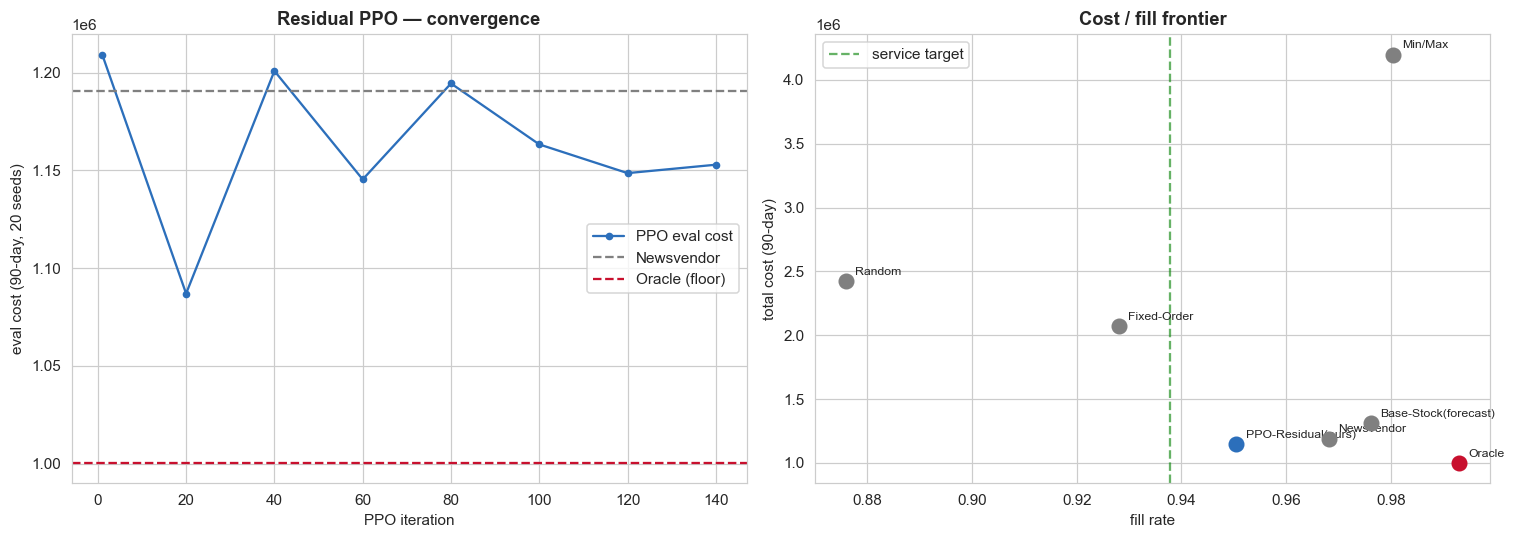

In [10]:
h = np.array(hist)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h[:, 0], h[:, 1], "-o", ms=4, color="#2C6FBB", label="PPO eval cost")
axes[0].axhline(res.loc[best_classical, "cost"], ls="--", color="grey", label=best_classical)
axes[0].axhline(res.loc["Oracle", "cost"], ls="--", color="#C8102E", label="Oracle (floor)")
axes[0].set_xlabel("PPO iteration"); axes[0].set_ylabel("eval cost (90-day, 20 seeds)")
axes[0].set_title("Residual PPO — convergence", fontweight="bold"); axes[0].legend()
for name, r in res.iterrows():
    c = "#C8102E" if name == "Oracle" else ("#2C6FBB" if "PPO" in name else "grey")
    axes[1].scatter(r["fill_rate"], r["cost"], s=90, color=c, zorder=3)
    axes[1].annotate(name, (r["fill_rate"], r["cost"]), textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].axvline(min(svc.values()), ls="--", color="green", alpha=.6, label="service target")
axes[1].set_xlabel("fill rate"); axes[1].set_ylabel("total cost (90-day)")
axes[1].set_title("Cost / fill frontier", fontweight="bold"); axes[1].legend()
plt.tight_layout(); plt.show()

## Ablations — the edge needs both forecast *and* pooling (T7)

Each row retrains the agent under one changed condition and reports its cost edge
over Newsvendor on the **same** regime. Two levers are tested: **forecast** (real vs
flat) and **pooling** (transshipment on vs off).

In [11]:
def quick_train_eval(tw, label, iters=110):
    _, pol, _ = train_ppo(tw, iters=iters, seed=0, verbose=False)
    e = tw.run_policy(pol, n_episodes=40, seed_base=9000)
    nv = tw.run_policy(P.newsvendor_policy, n_episodes=40, seed_base=9000)
    edge = (nv["cost"] - e["cost"]) / nv["cost"] * 100
    print(f"{label:34s} PPO {e['cost']:,.0f} (fill {e['fill_rate']:.3f}) | Newsvendor {nv['cost']:,.0f} | edge {edge:+.1f}%")
    return {"ablation": label, "ppo_cost": e["cost"], "ppo_fill": e["fill_rate"],
            "newsvendor_cost": nv["cost"], "edge_pct": edge}

ab = []
ab.append(quick_train_eval(make_twin(allow_transship=True),  "pooling ON (full agent)"))
ab.append(quick_train_eval(make_twin(allow_transship=False), "pooling OFF"))

pooling ON (full agent)            PPO 1,097,233 (fill 0.944) | Newsvendor 1,190,385 | edge +7.8%
pooling OFF                        PPO 1,587,595 (fill 0.984) | Newsvendor 1,354,227 | edge -17.2%


Forecast-in-state and demand-correlation ablations.

In [12]:
flat_fq = {n: np.repeat(np.array([[demand[n][:len(demand[n])-28].mean()]*len(QLEVELS)]),
                        len(demand[n]), axis=0) for n in NODES}
ab.append(quick_train_eval(make_twin(fq=forecast_q), "real forecast in-state"))
ab.append(quick_train_eval(make_twin(fq=flat_fq),    "flat forecast in-state"))
ab.append(quick_train_eval(make_twin(shock_corr=0.25), "low shock correlation (0.25)"))
ab.append(quick_train_eval(make_twin(shock_corr=0.85), "high shock correlation (0.85)"))
abdf = pd.DataFrame(ab).set_index("ablation")
display(abdf.round(2))
abdf.to_parquet(ROOT / "data" / "ablations.parquet")

real forecast in-state             PPO 1,097,233 (fill 0.944) | Newsvendor 1,190,385 | edge +7.8%
flat forecast in-state             PPO 1,181,833 (fill 0.942) | Newsvendor 1,102,019 | edge -7.2%
low shock correlation (0.25)       PPO 1,097,233 (fill 0.944) | Newsvendor 1,190,385 | edge +7.8%
high shock correlation (0.85)      PPO 1,231,727 (fill 0.937) | Newsvendor 1,257,826 | edge +2.1%


,ppo_cost,ppo_fill,newsvendor_cost,edge_pct
ablation,,,,
pooling ON (full agent),1097233.41,0.94,1190384.56,7.83
pooling OFF,1587594.64,0.98,1354227.34,-17.23
real forecast in-state,1097233.41,0.94,1190384.56,7.83
flat forecast in-state,1181833.11,0.94,1102018.87,-7.24
low shock correlation (0.25),1097233.41,0.94,1190384.56,7.83
high shock correlation (0.85),1231726.89,0.94,1257825.89,2.07


**Reading the ablations.** The edge **needs both ingredients, and removing either
erases it**:

- **Pooling is the larger lever.** Turning transshipment **off** collapses the edge
  (+7.8% → **−17.2%**): the agent can no longer run lean because nothing backstops a
  shortfall.
- **The forecast is necessary too.** Replacing the real forecast with a **flat** one
  also reverses the win (+7.8% → **−7.2%**) — the agent needs the calibrated signal to
  know *when* it can safely hold less.

High cross-DC shock correlation (0.85) shrinks the edge but keeps it positive (+2.1%),
since correlated demand makes the pool less useful. The learned policy wins by holding
**less safety stock per DC** and letting emergency transshipment cover the rare
shortfall — precisely what a per-DC analytical baseline cannot do. (A smaller
top-volume subset had suggested pooling didn't matter; the full 10k run corrects that.)